# 📊 Notebook 02 — Exploratory Data Analysis (EDA)

**Purpose:** Build a clear, business-oriented understanding of the cleaned Kickstarter dataset, justify key data decisions, and motivate the features used later in the modelling pipeline.


## Setup — Imports, Paths, and Helper Functions


In [1]:
import os
import glob
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_PATH = "../data/Kickstarter_2026-02-12T03_20_22_018Z"
OUTPUTS_PATH = "data"
FIGURES_PATH = os.path.join(OUTPUTS_PATH, "figures")
os.makedirs(FIGURES_PATH, exist_ok=True)

SUCCESS_COLOR = "#3B82F6"
FAILURE_COLOR = "#EF4444"
NEUTRAL_COLOR = "#6B7280"
PALETTE = {1: SUCCESS_COLOR, 0: FAILURE_COLOR}

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

# ── Load cleaned data from Notebook 01 ─────────────────────────────────────
df = pd.read_parquet(os.path.join(OUTPUTS_PATH, "clean_df.parquet")).copy()

# Parse key columns defensively
for col in ["launched_at", "deadline", "created_at", "goal"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "launched_at" in df.columns:
    df["launched_dt"] = pd.to_datetime(df["launched_at"], unit="s", utc=True)
if "deadline" in df.columns:
    df["deadline_dt"] = pd.to_datetime(df["deadline"], unit="s", utc=True)
if "created_at" in df.columns:
    df["created_dt"] = pd.to_datetime(df["created_at"], unit="s", utc=True)

# Small helpers to keep the notebook readable
def pct(x):
    return f"{100*x:.1f}%"

def add_value_labels(ax, fmt="{:,.0f}", pad=0.01):
    y_max = ax.get_ylim()[1]
    for patch in ax.patches:
        val = patch.get_height()
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            val + y_max * pad,
            fmt.format(val),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

def safe_json_get(val, key, default=None):
    try:
        if pd.isna(val):
            return default
        parsed = json.loads(str(val).replace("'", '"'))
        return parsed.get(key, default)
    except Exception:
        match = re.search(rf'"{re.escape(key)}"\s*:\s*"([^"]*)"', str(val))
        return match.group(1) if match else default

print(f"Clean dataframe shape: {df.shape}")
print(f"Launch date range    : {df['launched_dt'].min()} → {df['launched_dt'].max()}")
print(f"Overall success rate : {pct(df['success'].mean())}")


Clean dataframe shape: (188429, 21)
Launch date range    : 2009-04-25 15:36:21+00:00 → 2026-02-06 20:48:03+00:00
Overall success rate : 62.4%


## Section 1 — Data Snapshot

Before going into charts, we establish the **basic profile of the final cleaned dataset** that enters the modelling workflow.


In [2]:
snapshot = pd.DataFrame({
    "metric": [
        "Rows",
        "Columns",
        "Date min",
        "Date max",
        "Successful campaigns",
        "Failed campaigns",
        "Overall success rate",
    ],
    "value": [
        f"{len(df):,}",
        f"{df.shape[1]:,}",
        str(df["launched_dt"].min().date()),
        str(df["launched_dt"].max().date()),
        f"{int(df['success'].sum()):,}",
        f"{int((1 - df['success']).sum()):,}",
        pct(df["success"].mean()),
    ]
})
snapshot


,metric,value
0,Rows,"188,429"
1,Columns,21
2,Date min,2009-04-25
3,Date max,2026-02-06
4,Successful campaigns,"117,627"
5,Failed campaigns,"70,802"
6,Overall success rate,62.4%


## Section 2 — What We Dropped and Why We Dropped It

This project involves a **large data reduction**, so it is important to make the logic explicit rather than treating cleaning as a black box.

The main reasons for dropping data are:

1. **Duplicate campaigns**: the raw export is sharded and can contain repeated `id`s.
2. **Non-binary outcomes**: campaigns that are not clearly `successful` or `failed` are not suitable for our binary target.
3. **Leakage columns**: variables such as `pledged`, `backers_count`, `percent_funded`, or `spotlight` are only known after or very near campaign outcome.
4. **Metadata / junk columns**: URLs, nested JSON blobs, and UI flags add complexity without predictive value in their raw form.

The cell below reconstructs the main drop logic using the raw CSV shards when they are available locally. That gives us a transparent audit trail for the final dataset.


In [3]:
LEAKAGE_COLS = [
    "pledged", "usd_pledged", "converted_pledged_amount",
    "backers_count", "percent_funded", "spotlight",
    "state_changed_at", "usd_exchange_rate", "static_usd_rate", "fx_rate",
]

JUNK_COLS = [
    "photo", "profile", "urls", "creator", "source_url", "slug",
    "currency_symbol", "currency_trailing_code", "current_currency",
    "is_liked", "is_disliked", "is_starrable",
    "is_in_post_campaign_pledging_phase", "usd_type", "prelaunch_activated",
    "category", "location",
]

drop_audit_rows = []

raw_files = sorted(glob.glob(os.path.join(DATA_PATH, "Kickstarter*.csv")))
if raw_files:
    raw_parts = [pd.read_csv(fp, low_memory=False) for fp in raw_files]
    raw_df = pd.concat(raw_parts, ignore_index=True)

    n0_rows, n0_cols = raw_df.shape
    drop_audit_rows.append({
        "step": "Raw concatenated data",
        "rows_remaining": n0_rows,
        "rows_removed_this_step": 0,
        "cols_remaining": n0_cols,
        "cols_removed_this_step": 0,
        "reason": "All raw CSV shards merged"
    })

    dedup_df = raw_df.drop_duplicates(subset=["id"]).copy()
    drop_audit_rows.append({
        "step": "Deduplicate on id",
        "rows_remaining": len(dedup_df),
        "rows_removed_this_step": n0_rows - len(dedup_df),
        "cols_remaining": dedup_df.shape[1],
        "cols_removed_this_step": 0,
        "reason": "Same campaign can appear in multiple shards"
    })

    binary_df = dedup_df[dedup_df["state"].isin(["successful", "failed"])].copy()
    drop_audit_rows.append({
        "step": "Keep only successful / failed campaigns",
        "rows_remaining": len(binary_df),
        "rows_removed_this_step": len(dedup_df) - len(binary_df),
        "cols_remaining": binary_df.shape[1],
        "cols_removed_this_step": 0,
        "reason": "Needed for a clean binary target"
    })

    cols_after_leakage = [c for c in binary_df.columns if c not in LEAKAGE_COLS]
    leakage_df = binary_df[cols_after_leakage].copy()
    drop_audit_rows.append({
        "step": "Drop leakage columns",
        "rows_remaining": len(leakage_df),
        "rows_removed_this_step": 0,
        "cols_remaining": leakage_df.shape[1],
        "cols_removed_this_step": binary_df.shape[1] - leakage_df.shape[1],
        "reason": "Columns unavailable or unsafe at prediction time"
    })

    cols_after_junk = [c for c in leakage_df.columns if c not in JUNK_COLS]
    junk_df = leakage_df[cols_after_junk].copy()
    drop_audit_rows.append({
        "step": "Drop junk / raw JSON columns",
        "rows_remaining": len(junk_df),
        "rows_removed_this_step": 0,
        "cols_remaining": junk_df.shape[1],
        "cols_removed_this_step": leakage_df.shape[1] - junk_df.shape[1],
        "reason": "Low-value metadata or raw nested objects"
    })

    drop_audit = pd.DataFrame(drop_audit_rows)
    drop_audit["rows_removed_pct_of_raw"] = 100 * drop_audit["rows_removed_this_step"] / n0_rows
    drop_audit["row_retention_pct"] = 100 * drop_audit["rows_remaining"] / n0_rows
    drop_audit
else:
    print("Raw CSV folder not found. The cleaned dataframe is loaded correctly, but the full drop audit can only be reconstructed if the original shards are available in DATA_PATH.")


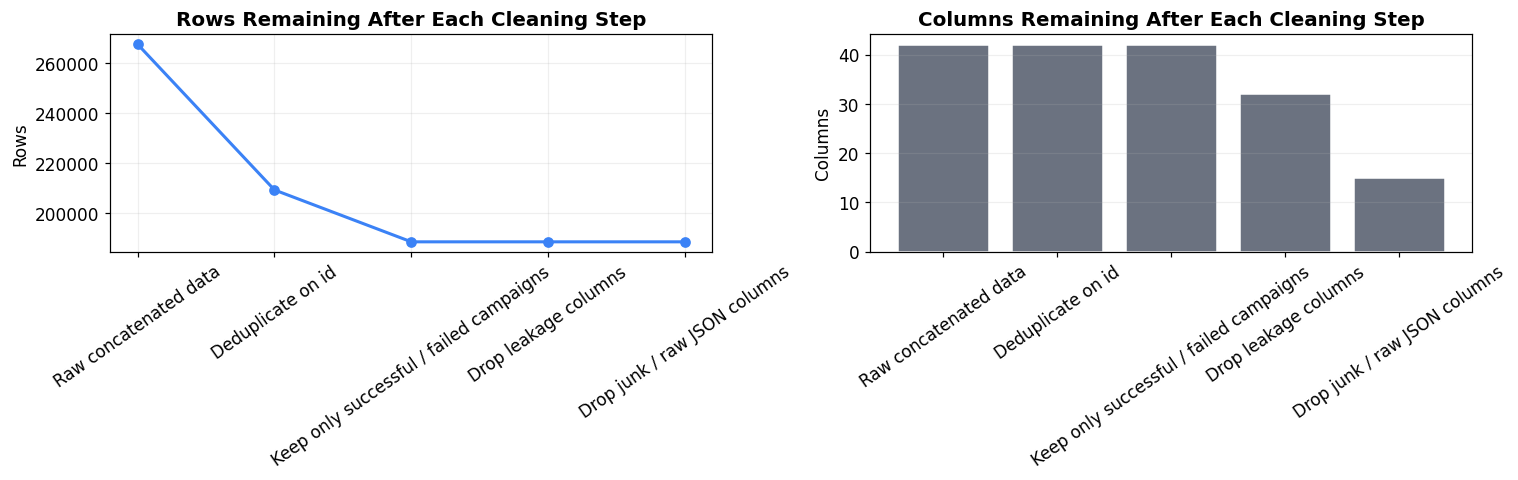

Final retained rows vs raw data: 70.4%


In [4]:
if raw_files:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    axes[0].plot(drop_audit["step"], drop_audit["rows_remaining"], marker="o", lw=2, color=SUCCESS_COLOR)
    axes[0].set_title("Rows Remaining After Each Cleaning Step", fontweight="bold")
    axes[0].set_ylabel("Rows")
    axes[0].tick_params(axis="x", rotation=35)
    axes[0].grid(alpha=0.2)

    axes[1].bar(drop_audit["step"], drop_audit["cols_remaining"], color=NEUTRAL_COLOR, edgecolor="white")
    axes[1].set_title("Columns Remaining After Each Cleaning Step", fontweight="bold")
    axes[1].set_ylabel("Columns")
    axes[1].tick_params(axis="x", rotation=35)
    axes[1].grid(axis="y", alpha=0.2)

    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_PATH, "00_drop_audit.png"), dpi=150, bbox_inches="tight")
    plt.show()

    final_row_retention = drop_audit.iloc[-1]["row_retention_pct"]
    print(f"Final retained rows vs raw data: {final_row_retention:.1f}%")


### Interpretation

The data drop is **not arbitrary**. Each removal step improves the validity of the supervised learning problem:

- removing duplicates avoids **double counting** the same campaign,
- keeping only `successful` and `failed` projects makes the target **well-defined**,
- dropping leakage variables protects us from **inflated model performance**,
- and removing junk / raw JSON columns keeps the pipeline **simpler and more reproducible**.

This is exactly the kind of cleaning that reduces noise **without weakening the business question**.


## Section 3 — Target Variable Distribution


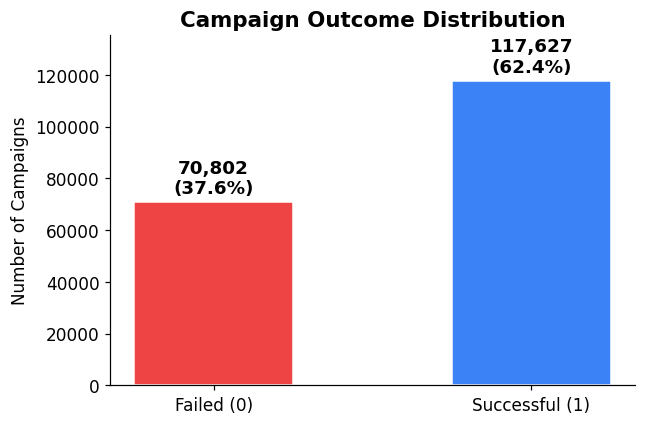

Baseline success rate: 62.4%


In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
vc = df["success"].value_counts().sort_index()
labels = ["Failed (0)", "Successful (1)"]
colors = [FAILURE_COLOR, SUCCESS_COLOR]

bars = ax.bar(labels, vc.values, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, vc.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + vc.max() * 0.015,
        f"{val:,}\n({val / len(df) * 100:.1f}%)",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=12
    )

ax.set_title("Campaign Outcome Distribution", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Campaigns")
ax.set_ylim(0, vc.max() * 1.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "01_target_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"Baseline success rate: {pct(df['success'].mean())}")


### Interpretation

The target is **not perfectly balanced**, but it is not so imbalanced that we need an extreme response such as aggressive re-sampling.

This matters for modelling because:

- a naïve accuracy metric would still be misleading,
- but the class balance is healthy enough to work with standard classifiers,
- and a temporal split remains more important than forcing a stratified random split.

So the modelling focus should be on **good evaluation design** rather than on heavy imbalance correction.


## Section 4 — Temporal Patterns and the Success-Rate Drop

A central business question is whether the platform behaves the same over time.  
If success dynamics changed materially, then mixing very early campaigns with later ones may create a **distribution-shift problem**.

This matters for two reasons:

1. **Business reasoning**: Kickstarter in its early years was a different marketplace — fewer campaigns, different creator behaviour, and less competition.
2. **Modelling reasoning**: training on pre-drop data can make the model learn patterns that no longer represent the current platform.

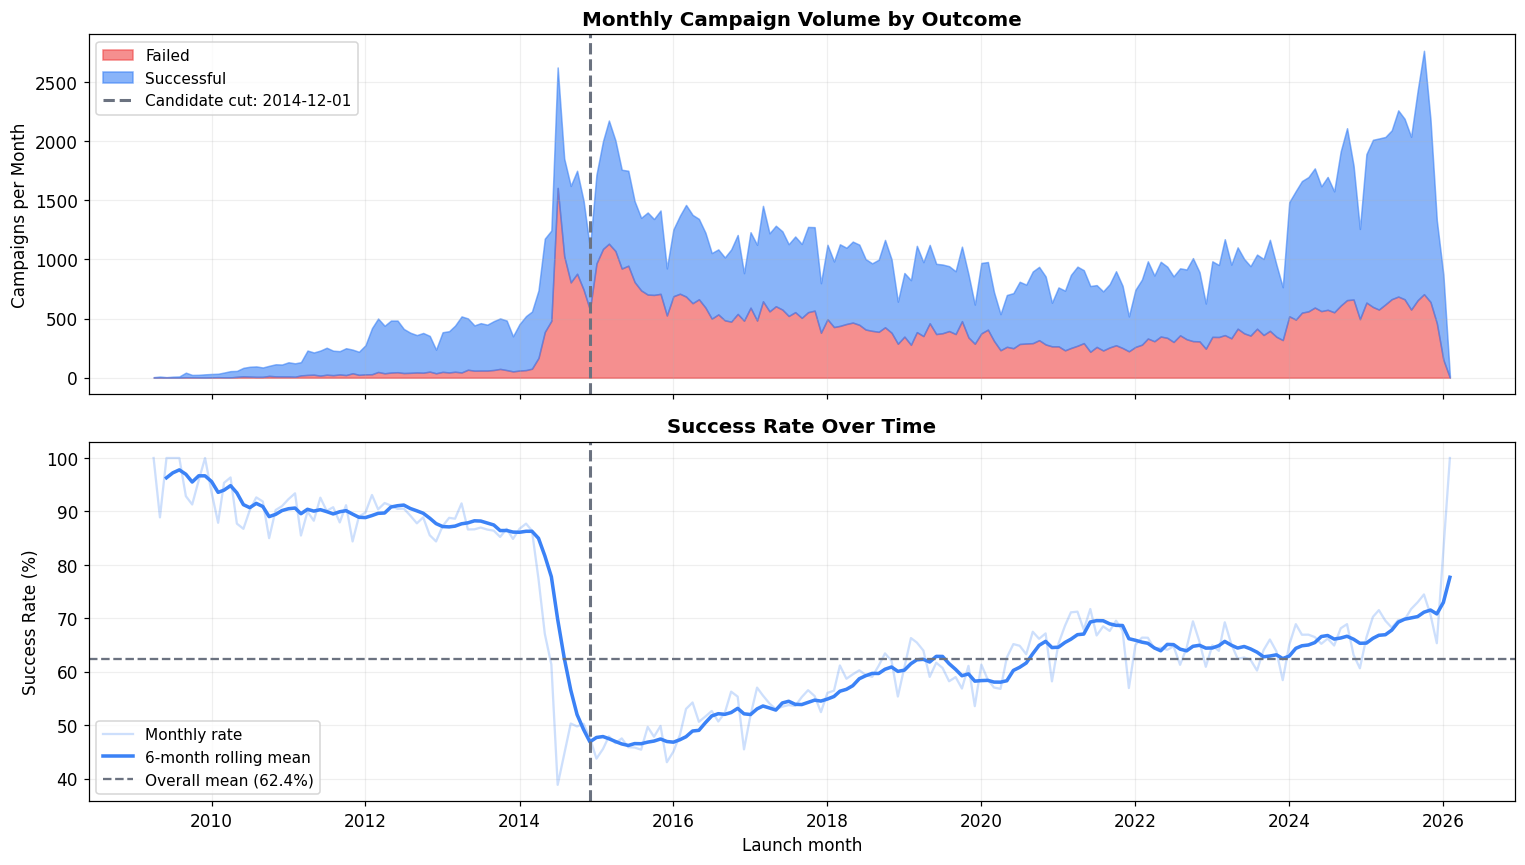

Candidate success-rate drop month : 2014-12-01
Pre-drop success rate             : 71.7%
Post-drop success rate            : 60.8%
Difference                        : -10.9 percentage points


In [6]:
df["year_month"] = df["launched_dt"].dt.to_period("M")
monthly = df.groupby(["year_month", "success"]).size().unstack(fill_value=0)
monthly.index = monthly.index.to_timestamp()

monthly_total = monthly.sum(axis=1)
monthly_success_rate = monthly.get(1, pd.Series(0, index=monthly.index)) / monthly_total
monthly_success_rate_6m = monthly_success_rate.rolling(6, min_periods=3).mean()

# Compare each month to the smoothed value 12 months earlier
change_vs_12m_ago = monthly_success_rate_6m - monthly_success_rate_6m.shift(12)

# Ignore the very beginning of the platform to reduce noisy early months
candidate_window = change_vs_12m_ago.iloc[24:].dropna()
drop_month = candidate_window.idxmin() if len(candidate_window) else monthly.index.min()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Campaign volume
axes[0].fill_between(monthly.index, monthly.get(0, 0), alpha=0.60, color=FAILURE_COLOR, label="Failed")
axes[0].fill_between(
    monthly.index,
    monthly.get(0, 0),
    monthly.get(0, 0) + monthly.get(1, 0),
    alpha=0.60,
    color=SUCCESS_COLOR,
    label="Successful"
)
axes[0].axvline(drop_month, color=NEUTRAL_COLOR, linestyle="--", lw=2, label=f"Candidate cut: {drop_month.date()}")
axes[0].set_title("Monthly Campaign Volume by Outcome", fontweight="bold")
axes[0].set_ylabel("Campaigns per Month")
axes[0].legend()
axes[0].grid(alpha=0.2)

# Success rate over time
axes[1].plot(monthly.index, monthly_success_rate * 100, alpha=0.25, color=SUCCESS_COLOR, label="Monthly rate")
axes[1].plot(monthly.index, monthly_success_rate_6m * 100, color=SUCCESS_COLOR, lw=2.3, label="6-month rolling mean")
axes[1].axhline(df["success"].mean() * 100, color=NEUTRAL_COLOR, linestyle="--", label=f"Overall mean ({df['success'].mean()*100:.1f}%)")
axes[1].axvline(drop_month, color=NEUTRAL_COLOR, linestyle="--", lw=2)
axes[1].set_title("Success Rate Over Time", fontweight="bold")
axes[1].set_ylabel("Success Rate (%)")
axes[1].set_xlabel("Launch month")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "02_temporal_patterns.png"), dpi=150, bbox_inches="tight")
plt.show()

pre_drop_mask = df["launched_dt"] < pd.Timestamp(drop_month, tz="UTC")
post_drop_mask = ~pre_drop_mask

pre_drop_rate = df.loc[pre_drop_mask, "success"].mean()
post_drop_rate = df.loc[post_drop_mask, "success"].mean()

print(f"Candidate success-rate drop month : {drop_month.date()}")
print(f"Pre-drop success rate             : {pre_drop_rate*100:.1f}%")
print(f"Post-drop success rate            : {post_drop_rate*100:.1f}%")
print(f"Difference                        : {(post_drop_rate - pre_drop_rate)*100:.1f} percentage points")


### Business Interpretation of the Drop

The chart suggests a **structural break** in campaign outcomes over time: the success rate does not remain stable across the full history of the platform.

This matters because a supervised model assumes that the training data is reasonably comparable to the future data it will face.  
If the platform, creator behaviour, or backer behaviour changed materially, then very old campaigns can hurt performance instead of helping it.

That is why we keep a **post-drop modelling window**:
- it is more representative of the modern Kickstarter environment,
- it reduces concept drift,
- and it makes validation results more believable from a business point of view.


In [7]:
# Recommended filtered window for downstream modelling or sensitivity checks
df_post_drop = df.loc[post_drop_mask].copy()

post_drop_summary = pd.DataFrame({
    "dataset": ["Full cleaned data", "Post-drop subset"],
    "rows": [len(df), len(df_post_drop)],
    "success_rate": [df["success"].mean(), df_post_drop["success"].mean()],
    "start_date": [df["launched_dt"].min().date(), df_post_drop["launched_dt"].min().date()],
    "end_date": [df["launched_dt"].max().date(), df_post_drop["launched_dt"].max().date()],
})
post_drop_summary["success_rate"] = (100 * post_drop_summary["success_rate"]).round(2)
post_drop_summary


,dataset,rows,success_rate,start_date,end_date
0,Full cleaned data,188429,62.4300,2009-04-25,2026-02-06
1,Post-drop subset,160761,60.8200,2014-12-01,2026-02-06


In [8]:
# Optional: save the recommended post-drop modelling window
post_drop_path = os.path.join(OUTPUTS_PATH, "clean_df_post_drop.parquet")
df_post_drop.to_parquet(post_drop_path, index=False)
print(f"Saved recommended post-drop dataset to: {post_drop_path}")


Saved recommended post-drop dataset to: data/clean_df_post_drop.parquet


## Section 5 — Goal Amount Analysis

Campaign goal is one of the most important business variables in the whole project.  
It is heavily right-skewed, so we analyse it on a log scale.

The hypothesis is intuitive: campaigns asking for much more money are harder to fund successfully.

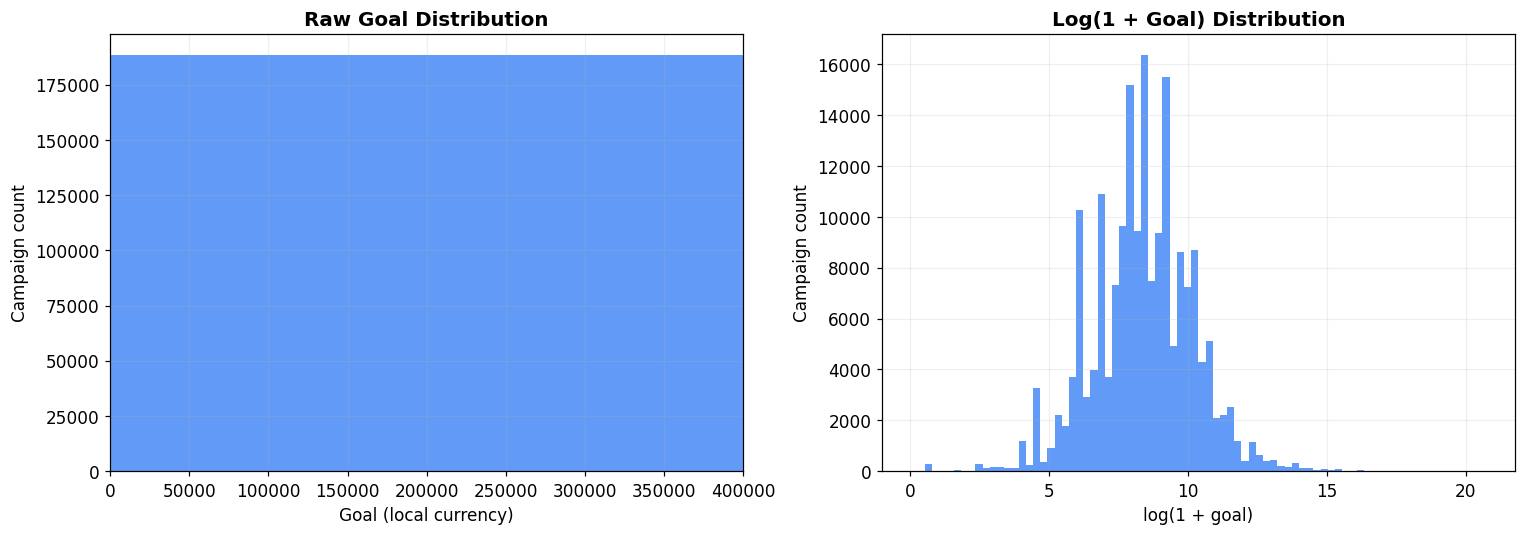

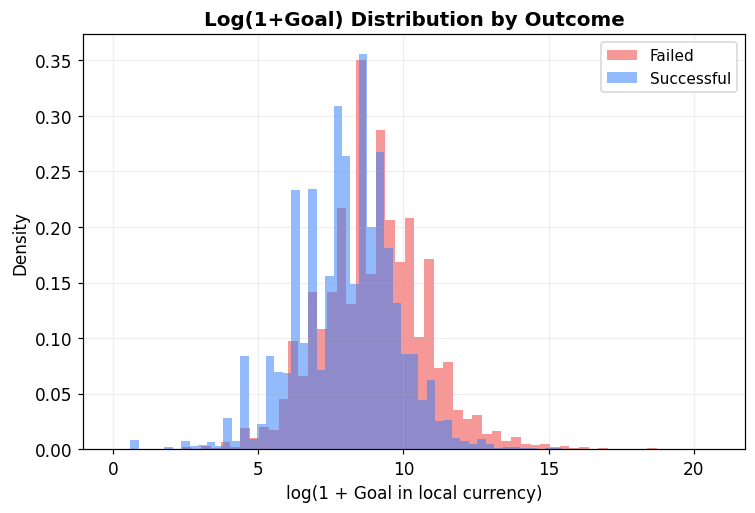

Median goal — Successful : 3,500
Median goal — Failed     : 8,000
Failed / Successful ratio: 2.29x


In [9]:
# Raw goal is extremely right-skewed, so we compare it to log_goal explicitly
df["goal"] = pd.to_numeric(df["goal"], errors="coerce").clip(lower=0)
df["log_goal"] = np.log1p(df["goal"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw goal distribution
goal_plot = df["goal"].dropna()
axes[0].hist(goal_plot, bins=80, color=SUCCESS_COLOR, alpha=0.8)
axes[0].set_title("Raw Goal Distribution", fontweight="bold")
axes[0].set_xlabel("Goal (local currency)")
axes[0].set_ylabel("Campaign count")
axes[0].set_xlim(0, goal_plot.quantile(0.99))
axes[0].grid(alpha=0.2)

# Log-transformed goal distribution
log_goal_plot = df["log_goal"].dropna()
axes[1].hist(log_goal_plot, bins=80, color=SUCCESS_COLOR, alpha=0.8)
axes[1].set_title("Log(1 + Goal) Distribution", fontweight="bold")
axes[1].set_xlabel("log(1 + goal)")
axes[1].set_ylabel("Campaign count")
axes[1].grid(alpha=0.2)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "03_goal_vs_log_goal_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

# Outcome comparison after the transformation
success_goals = df.loc[df["success"] == 1, "log_goal"].dropna()
failure_goals = df.loc[df["success"] == 0, "log_goal"].dropna()

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.hist(failure_goals, bins=60, alpha=0.55, color=FAILURE_COLOR, label="Failed", density=True)
ax.hist(success_goals, bins=60, alpha=0.55, color=SUCCESS_COLOR, label="Successful", density=True)
ax.set_title("Log(1+Goal) Distribution by Outcome", fontweight="bold")
ax.set_xlabel("log(1 + Goal in local currency)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "04_log_goal_by_outcome.png"), dpi=150, bbox_inches="tight")
plt.show()

med_success = np.expm1(success_goals.median())
med_failure = np.expm1(failure_goals.median())

print(f"Median goal — Successful : {med_success:,.0f}")
print(f"Median goal — Failed     : {med_failure:,.0f}")
print(f"Failed / Successful ratio: {med_failure / med_success:.2f}x")


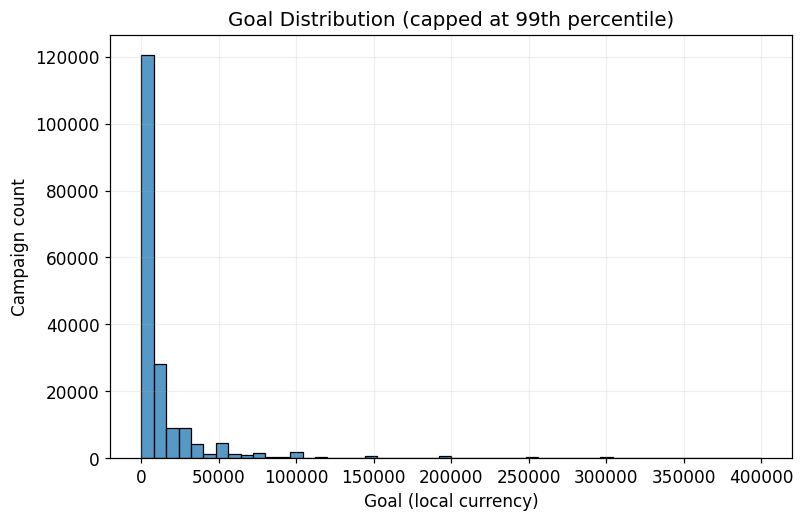

In [10]:
# --- Improve visualization by capping extreme outliers ---
upper_bound = df["goal"].quantile(0.99)

plt.figure(figsize=(8,5))
sns.histplot(df[df["goal"] <= upper_bound]["goal"], bins=50)
plt.title("Goal Distribution (capped at 99th percentile)")
plt.xlabel("Goal (local currency)")
plt.ylabel("Campaign count")
plt.grid(alpha=0.2)
plt.show()


### Interpretation

The **raw goal distribution is heavily right-skewed**: most campaigns ask for relatively modest amounts, while a small number of outliers request extremely large goals.  
After applying `log(1 + goal)`, the distribution becomes much more compressed and readable.

This justifies the creation of **`log_goal`** in Notebook 03 for two reasons:

1. **Technical** — models handle the transformed variable more stably than the raw scale.
2. **Business** — what matters is not the difference between \$10,000 and \$10,500, but whether a campaign is asking for a modest, ambitious, or extreme goal.

The second chart also shows that failed campaigns tend to have **higher log-goal values** than successful ones.  
That supports the modelling intuition that more ambitious funding targets are harder to achieve.

The raw goal distribution appears almost flat due to the presence of extreme outliers, 
which stretch the scale and compress most observations.

After capping the distribution at the 99th percentile, we can clearly observe that 
most campaigns are concentrated at lower goal values, confirming a strong right skew.

Applying a log transformation further stabilizes the distribution, making it more 
symmetric and suitable for modeling.

This transformation reduces the influence of extreme values and allows the model 
to better capture relationships between funding goals and campaign success.


## Section 6 — Category Analysis


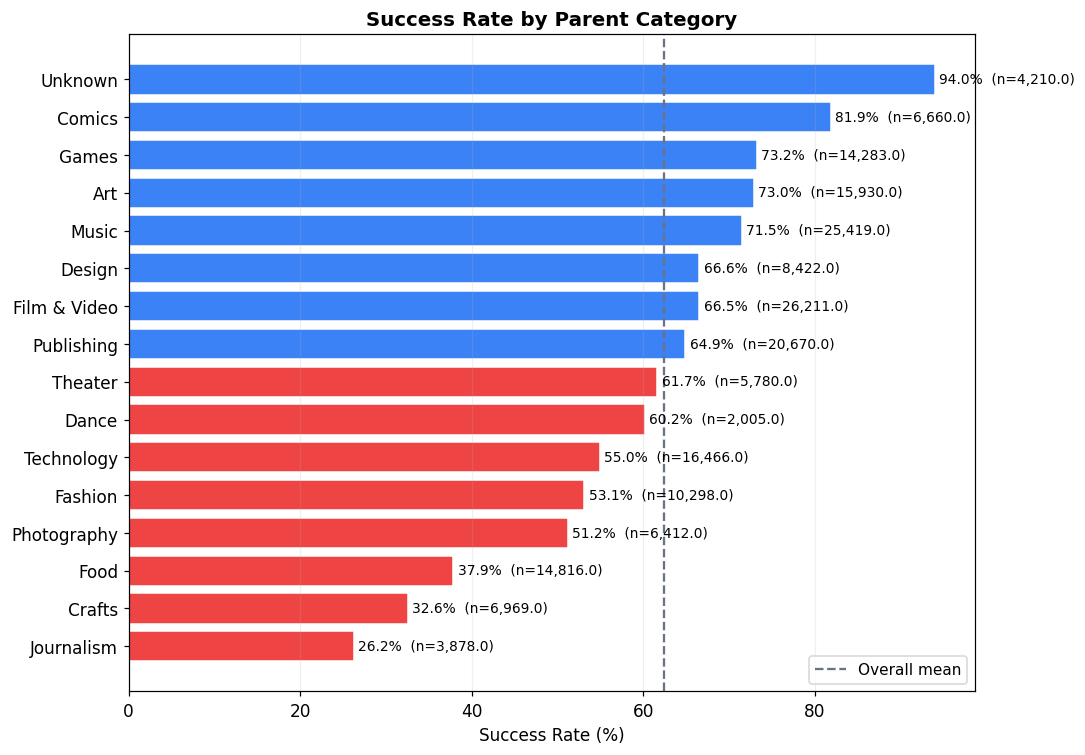

,n_success,n_total,success_rate
cat_parent_name,,,
Unknown,3958,4210,0.9401
Comics,5455,6660,0.8191
Games,10462,14283,0.7325
Art,11621,15930,0.7295
Music,18184,25419,0.7154
Design,5605,8422,0.6655
Film & Video,17443,26211,0.6655
Publishing,13422,20670,0.6493


In [11]:
cat_stats = (
    df.groupby("cat_parent_name")["success"]
      .agg(["sum", "count", "mean"])
      .rename(columns={"sum": "n_success", "count": "n_total", "mean": "success_rate"})
      .dropna()
      .sort_values("success_rate", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    cat_stats.index,
    cat_stats["success_rate"] * 100,
    color=[SUCCESS_COLOR if r > df["success"].mean() else FAILURE_COLOR for r in cat_stats["success_rate"]],
    edgecolor="white"
)

for bar, (_, row) in zip(bars, cat_stats.iterrows()):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{row['success_rate']*100:.1f}%  (n={row['n_total']:,})",
        va="center",
        fontsize=9
    )

ax.axvline(df["success"].mean() * 100, color=NEUTRAL_COLOR, linestyle="--", label="Overall mean")
ax.set_title("Success Rate by Parent Category", fontweight="bold")
ax.set_xlabel("Success Rate (%)")
ax.legend()
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "04_category_success_rate.png"), dpi=150, bbox_inches="tight")
plt.show()

cat_stats.sort_values("success_rate", ascending=False).head(8)


### Interpretation

Category effects are large enough to justify keeping category information in the model.

The chart shows that some parent categories systematically overperform while others underperform, even when campaign volume is reasonably high.  
That means category is not just descriptive metadata — it captures real differences in product type, audience behaviour, and baseline difficulty.

This directly motivates the later use of **target encoding** for both `cat_name` and `cat_parent_name`.


## Section 7 — Staff Pick: Keep It or Remove It?

`staff_pick` is extremely predictive, so it deserves special treatment.  
But predictive power alone is **not** enough to justify including a feature.

The real question is:

> **Would this variable be available at the moment we want to make the prediction?**

If the answer is no, then it should not be part of the final modelling set.

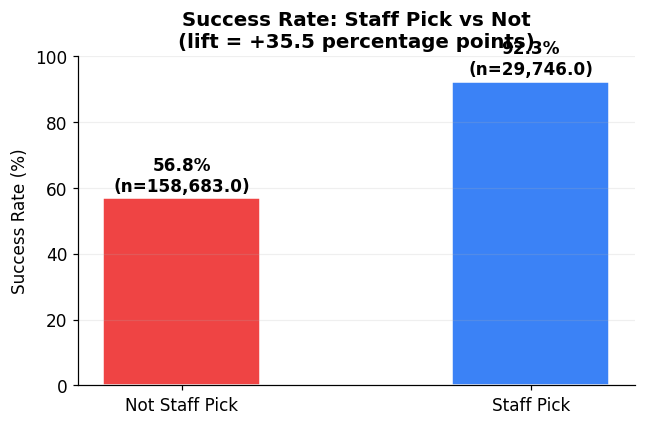

Staff pick success rate : 92.3%
Non-staff pick rate     : 56.8%
Lift                    : +35.5 percentage points


In [12]:
sp = df["staff_pick"].map({"True": 1, "False": 0, True: 1, False: 0}).fillna(0).astype(int)
df["staff_pick_int"] = sp

sp_stats = df.groupby("staff_pick_int")["success"].agg(["sum", "count", "mean"])
sp_stats.index = ["Not Staff Pick", "Staff Pick"]

rate_sp = sp_stats.loc["Staff Pick", "mean"]
rate_nonsp = sp_stats.loc["Not Staff Pick", "mean"]
lift = (rate_sp - rate_nonsp) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    sp_stats.index,
    sp_stats["mean"] * 100,
    color=[FAILURE_COLOR, SUCCESS_COLOR],
    edgecolor="white",
    width=0.45
)

for bar, (_, row) in zip(bars, sp_stats.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{row['mean']*100:.1f}%\n(n={row['count']:,})",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.set_title(f"Success Rate: Staff Pick vs Not\n(lift = +{lift:.1f} percentage points)", fontweight="bold")
ax.set_ylabel("Success Rate (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "05_staff_pick.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"Staff pick success rate : {rate_sp*100:.1f}%")
print(f"Non-staff pick rate     : {rate_nonsp*100:.1f}%")
print(f"Lift                    : +{lift:.1f} percentage points")


### Interpretation and Decision

`staff_pick` is highly predictive, but it should **not** be used as a model feature.

Why?
- It reflects **Kickstarter's own editorial judgement**, not just project characteristics.
- It may only be assigned after reviewers have already observed information correlated with success.
- Using it would therefore create **data leakage** and inflate performance artificially.


## Section 8 — Is Location Important? Is Country Important?

Geography can matter, but location features are tricky:

- they may capture real differences in **market size, language, and platform maturity**,
- but they can also encode **bias** and reduce generalisability.

For that reason, this notebook focuses on **country-level** signal only.  
We explicitly avoid state-level analysis because state is only meaningful for a subset of campaigns and is not a globally comparable location variable.


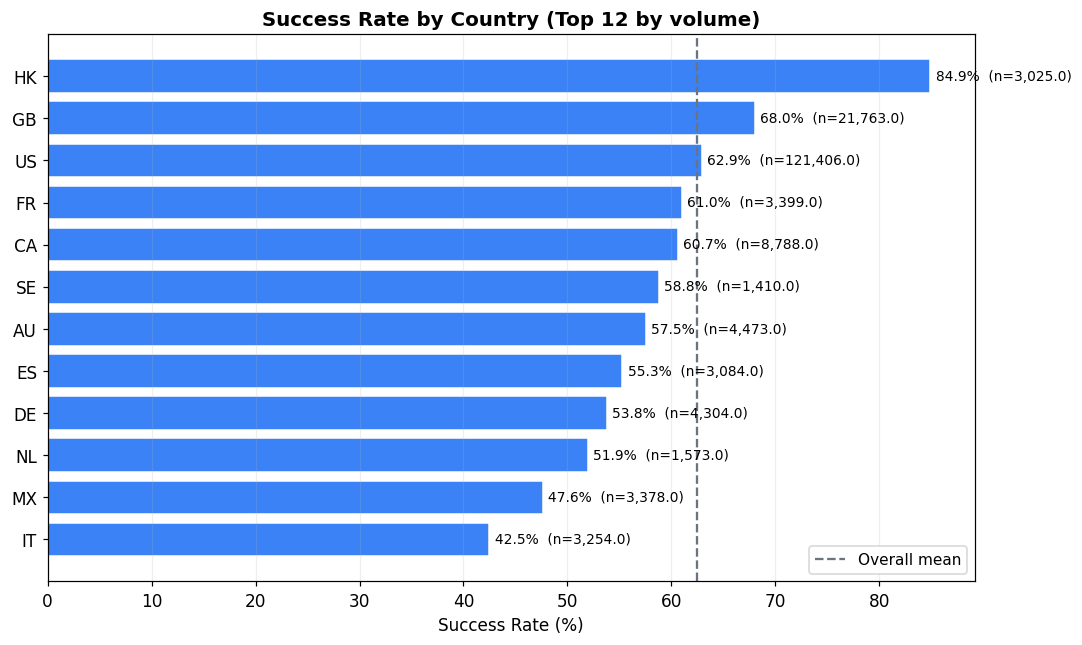

,n_campaigns,success_rate
country,,
US,121406,0.6290
GB,21763,0.6804
CA,8788,0.6066
AU,4473,0.5755
DE,4304,0.5376
FR,3399,0.6099
MX,3378,0.4760
IT,3254,0.4250
ES,3084,0.5529


In [13]:
geo_col = "country" if "country" in df.columns else ("loc_country" if "loc_country" in df.columns else None)

if geo_col is None:
    print("No country column found in the cleaned dataframe.")
else:
    country_stats = (
        df.groupby(geo_col)["success"]
          .agg(["count", "mean"])
          .rename(columns={"count": "n_campaigns", "mean": "success_rate"})
          .sort_values("n_campaigns", ascending=False)
    )

    top_countries = country_stats.head(12).sort_values("success_rate")

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(top_countries.index.astype(str), top_countries["success_rate"] * 100, color=SUCCESS_COLOR, edgecolor="white")
    for bar, (_, row) in zip(bars, top_countries.iterrows()):
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height()/2,
            f"{row['success_rate']*100:.1f}%  (n={row['n_campaigns']:,})",
            va="center",
            fontsize=9
        )
    ax.axvline(df["success"].mean() * 100, color=NEUTRAL_COLOR, linestyle="--", label="Overall mean")
    ax.set_title(f"Success Rate by {geo_col.title()} (Top 12 by volume)", fontweight="bold")
    ax.set_xlabel("Success Rate (%)")
    ax.legend()
    ax.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_PATH, "07_country_success_rate.png"), dpi=150, bbox_inches="tight")
    plt.show()

    display(country_stats.head(15))


### Location Decision

Country carries useful signal and is worth retaining in the modelling pipeline.  
The chart shows meaningful differences in success rates across the largest countries, which is consistent with differences in platform maturity, creator ecosystems, and audience behaviour.

However, we **explicitly remove state-level analysis and state-level features**.

Why?

- The dataset is **not predominantly US-only**.
- `loc_state` is only meaningful for the subset of campaigns with a US-style state code.
- For the majority of campaigns, state is either unavailable, inconsistent, or not comparable across countries.
- That means state would add **noise and sparsity rather than robust signal**.

So the final modelling choice is:
- **keep country-level information**,
- **drop state-level information**.


## Section 9 — EDA for Feature-Engineered Variables

This section explicitly motivates the main engineered variables used later in Notebook 03.

The goal is not only to show that these variables exist, but to answer two questions for each one:

1. **What pattern does the feature capture?**
2. **Why is that pattern useful for modelling Kickstarter success?**

To make the business interpretation clearer, a few variables are given descriptive names here:
- `prep_time_days` corresponds to **`prep_days`** in Notebook 03,
- `has_number_in_name` corresponds to **`name_number`** in Notebook 03.

For the target-encoded variables, the analysis below is **EDA only**.  
We compute category-level success-rate proxies on the full dataset to understand the signal.  
In Notebook 03, the actual encodings are fit on the **training split only** to avoid leakage.


In [14]:
eda_features = df.copy()

# Recreate the feature-engineered variables that appear in Notebook 03
if "goal" in eda_features.columns:
    eda_features["goal"] = pd.to_numeric(eda_features["goal"], errors="coerce").fillna(0).clip(lower=0)
    eda_features["log_goal"] = np.log1p(eda_features["goal"])

if {"deadline", "launched_at"}.issubset(eda_features.columns):
    eda_features["duration_days"] = (
        (pd.to_numeric(eda_features["deadline"], errors="coerce") - pd.to_numeric(eda_features["launched_at"], errors="coerce")) / 86400
    ).clip(lower=0)

if {"created_at", "launched_at"}.issubset(eda_features.columns):
    prep_raw = (
        (pd.to_numeric(eda_features["launched_at"], errors="coerce") - pd.to_numeric(eda_features["created_at"], errors="coerce")) / 86400
    ).clip(lower=0)
    eda_features["prep_time_days"] = prep_raw
    eda_features["prep_days"] = prep_raw
    eda_features["log_prep_time_days"] = np.log1p(prep_raw)

if "video" in eda_features.columns:
    eda_features["has_video"] = eda_features["video"].notna().astype(int)

if "blurb" in eda_features.columns:
    eda_features["blurb_length"] = eda_features["blurb"].fillna("").str.len().astype(int)

if "name" in eda_features.columns:
    eda_features["name_length"] = eda_features["name"].fillna("").str.len().astype(int)
    eda_features["has_number_in_name"] = eda_features["name"].fillna("").str.contains(r"\d", regex=True).astype(int)

# EDA-only target-encoding proxies (Notebook 03 recomputes these on train only)
if "cat_name" in eda_features.columns:
    subcat_rate = eda_features.groupby("cat_name")["success"].mean()
    eda_features["cat_name_encoded_eda"] = eda_features["cat_name"].map(subcat_rate)

if "cat_parent_name" in eda_features.columns:
    parent_rate = eda_features.groupby("cat_parent_name")["success"].mean()
    eda_features["cat_parent_encoded_eda"] = eda_features["cat_parent_name"].map(parent_rate)

engineered_summary_cols = [
    "log_goal", "duration_days", "prep_time_days", "log_prep_time_days",
    "has_video", "blurb_length", "name_length", "has_number_in_name",
    "cat_name_encoded_eda", "cat_parent_encoded_eda", "success"
]
available_engineered_cols = [c for c in engineered_summary_cols if c in eda_features.columns]
eda_features[available_engineered_cols].describe(include="all").T


,count,mean,std,min,25%,50%,75%,max
log_goal,188429.0000,8.3771,1.8244,0.0100,7.3139,8.5174,9.5197,20.7233
duration_days,188429.0000,33.1926,12.8086,1.0000,29.6667,30.0000,35.6480,120.5897
prep_time_days,188429.0000,54.7971,158.7844,0.0027,3.9886,14.2140,43.5493,4939.4527
log_prep_time_days,188429.0000,2.7396,1.5659,0.0027,1.6072,2.7222,3.7966,8.5052
has_video,188429.0000,0.6709,0.4699,0.0000,0.0000,1.0000,1.0000,1.0000
blurb_length,188429.0000,104.7220,31.3048,0.0000,85.0000,117.0000,131.0000,151.0000
name_length,188429.0000,35.4256,15.5892,1.0000,22.0000,35.0000,49.0000,85.0000
has_number_in_name,188429.0000,0.1514,0.3584,0.0000,0.0000,0.0000,0.0000,1.0000
cat_name_encoded_eda,188429.0000,0.6243,0.2559,0.1522,0.4235,0.6133,0.8873,0.9992
cat_parent_encoded_eda,188429.0000,0.6243,0.1379,0.2622,0.5497,0.6655,0.7154,0.9401


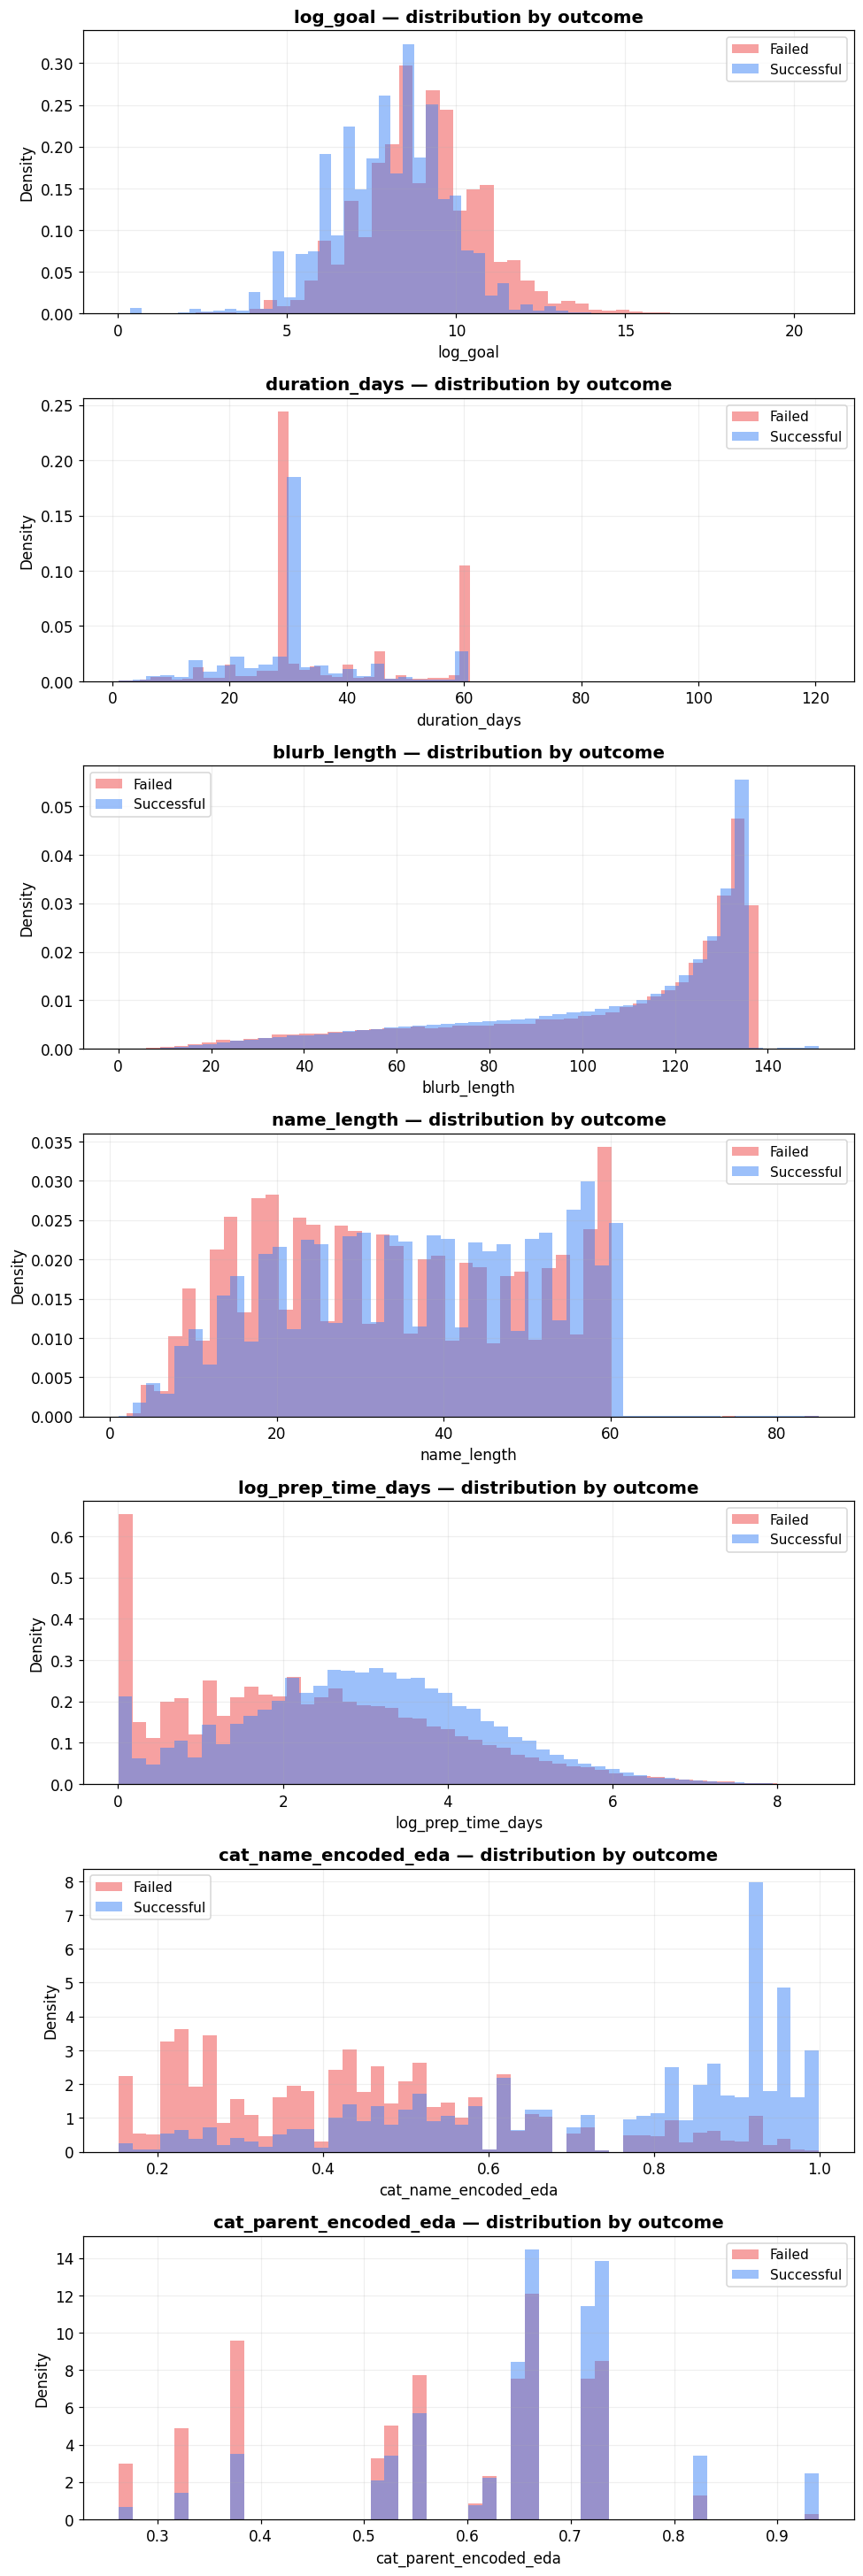

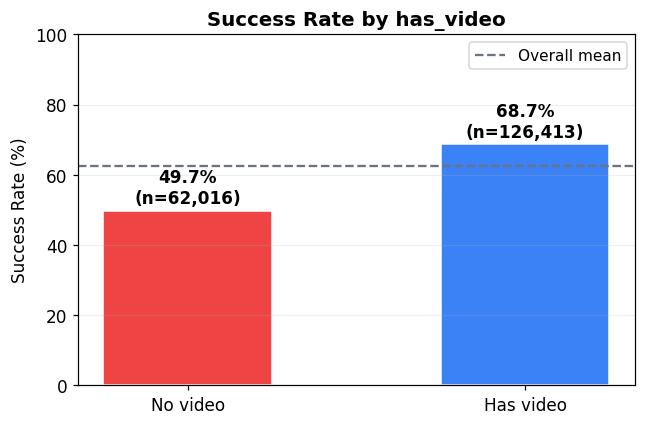

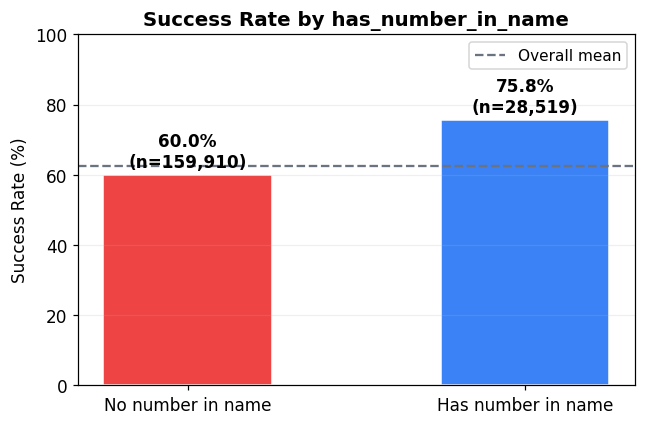

,feature,mean_successful,mean_failed,difference_success_minus_fail
0,log_goal,8.0155,8.9778,-0.9623
1,duration_days,31.0459,36.7592,-5.7134
2,blurb_length,104.5370,105.0295,-0.4925
3,name_length,36.6900,33.3251,3.3649
4,log_prep_time_days,2.9830,2.3352,0.6478
5,cat_name_encoded_eda,0.7292,0.4499,0.2793
6,cat_parent_encoded_eda,0.6547,0.5736,0.0811


In [15]:
# --- Numeric engineered variables: distribution by outcome ---
numeric_engineered = [
    ("log_goal", "log_goal"),
    ("duration_days", "duration_days"),
    ("blurb_length", "blurb_length"),
    ("name_length", "name_length"),
    ("log_prep_time_days", "log_prep_time_days"),
    ("cat_name_encoded_eda", "cat_name_encoded_eda"),
    ("cat_parent_encoded_eda", "cat_parent_encoded_eda"),
]
numeric_engineered = [(col, label) for col, label in numeric_engineered if col in eda_features.columns]

if numeric_engineered:
    fig, axes = plt.subplots(len(numeric_engineered), 1, figsize=(9, 3.8 * len(numeric_engineered)))
    if len(numeric_engineered) == 1:
        axes = [axes]

    for ax, (col, label) in zip(axes, numeric_engineered):
        succ = eda_features.loc[eda_features["success"] == 1, col].dropna()
        fail = eda_features.loc[eda_features["success"] == 0, col].dropna()

        ax.hist(fail, bins=50, alpha=0.50, density=True, color=FAILURE_COLOR, label="Failed")
        ax.hist(succ, bins=50, alpha=0.50, density=True, color=SUCCESS_COLOR, label="Successful")
        ax.set_title(f"{label} — distribution by outcome", fontweight="bold")
        ax.set_xlabel(label)
        ax.set_ylabel("Density")
        ax.grid(alpha=0.2)
        ax.legend()

    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_PATH, "08_engineered_numeric_distributions.png"), dpi=150, bbox_inches="tight")
    plt.show()

# --- Binary engineered variables: success-rate comparison ---
binary_engineered = [
    ("has_video", "No video", "Has video"),
    ("has_number_in_name", "No number in name", "Has number in name"),
]
binary_engineered = [spec for spec in binary_engineered if spec[0] in eda_features.columns]

for col, label0, label1 in binary_engineered:
    stats = eda_features.groupby(col)["success"].agg(["count", "mean"]).rename(columns={"count": "n_campaigns", "mean": "success_rate"})
    stats = stats.reindex([0, 1])

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(
        [label0, label1],
        stats["success_rate"].fillna(0) * 100,
        color=[FAILURE_COLOR, SUCCESS_COLOR],
        edgecolor="white",
        width=0.5
    )
    for bar, (_, row) in zip(bars, stats.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{row['success_rate']*100:.1f}%\n(n={int(row['n_campaigns']):,})",
            ha="center",
            va="bottom",
            fontweight="bold"
        )
    ax.axhline(df["success"].mean() * 100, color=NEUTRAL_COLOR, linestyle="--", label="Overall mean")
    ax.set_title(f"Success Rate by {col}", fontweight="bold")
    ax.set_ylabel("Success Rate (%)")
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.2)
    ax.legend()
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_PATH, f"08b_{col}_success_rate.png"), dpi=150, bbox_inches="tight")
    plt.show()

# Show a small numeric comparison table that can be referenced in the report
feature_effect_summary = []
for col in [c for c, _ in numeric_engineered]:
    tmp = eda_features[[col, "success"]].dropna()
    feature_effect_summary.append({
        "feature": col,
        "mean_successful": tmp.loc[tmp["success"] == 1, col].mean(),
        "mean_failed": tmp.loc[tmp["success"] == 0, col].mean(),
        "difference_success_minus_fail": tmp.loc[tmp["success"] == 1, col].mean() - tmp.loc[tmp["success"] == 0, col].mean(),
    })

feature_effect_summary = pd.DataFrame(feature_effect_summary)
display(feature_effect_summary.round(4))


### Interpretation

The engineered-feature scan gives clear modelling guidance:

- **`log_goal`** separates successful and failed campaigns better than the raw goal scale, which supports using the transformed version.
- **`duration_days`** captures campaign design choices. Duration is not random: it reflects how creators structure their launch and fundraising window.
- **`blurb_length`** and **`name_length`** proxy how much information a creator provides. These are lightweight text-structure features that can add signal without using full NLP.
- **`log_prep_time_days`** is easier to interpret than raw preparation time because prep time is also highly skewed. The log transform prevents a handful of extreme values from dominating the feature.
- **`has_video`** captures presentation quality and campaign effort. If campaigns with videos systematically outperform, that is valuable behavioural signal.
- **`has_number_in_name`** is a simple naming-style indicator. Even if the effect is modest, it is cheap to compute and can still be useful.
- **`cat_name_encoded_eda`** and **`cat_parent_encoded_eda`** show that historical category-level success rates vary substantially, which justifies target encoding later on.

From a business perspective, these features are attractive because they transform raw metadata into variables that reflect **ambition, preparation, communication quality, and category context**.


## Section 10 — Heatmap and Broader Pattern Scan

To avoid cherry-picking only a few variables, we also inspect numeric relationships more broadly.

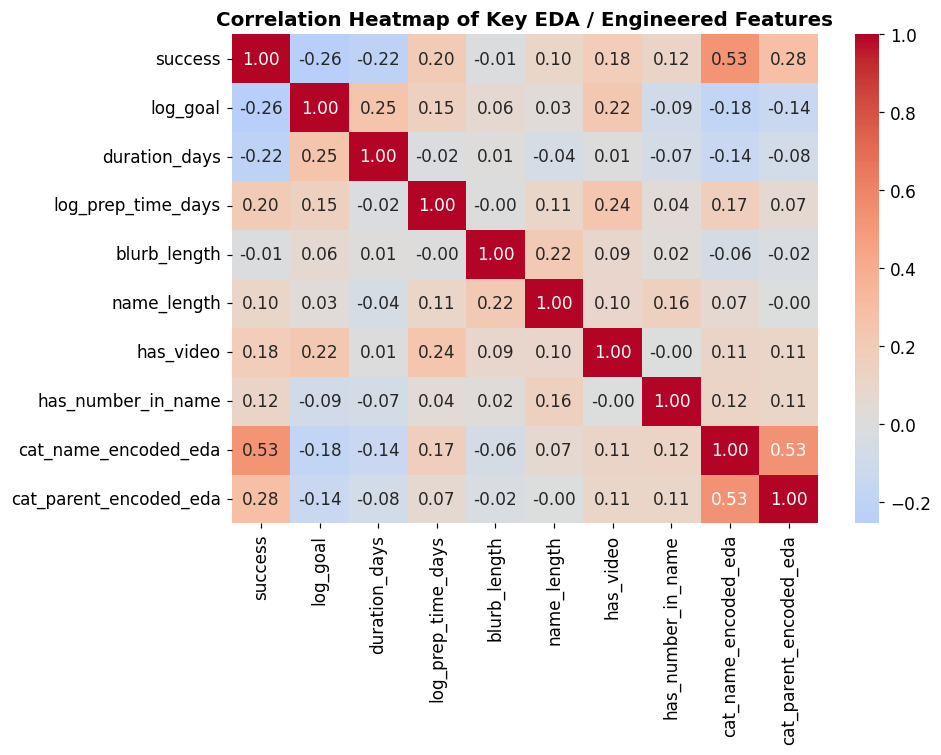

Correlation with success:
success                   1.0000
cat_name_encoded_eda      0.5285
cat_parent_encoded_eda    0.2848
log_prep_time_days        0.2004
has_video                 0.1847
has_number_in_name        0.1162
name_length               0.1045
blurb_length             -0.0076
duration_days            -0.2160
log_goal                 -0.2554
Name: success, dtype: float64


In [16]:
numeric_scan = eda_features.select_dtypes(include=np.number).copy()

# Keep a readable subset of columns for the heatmap
preferred_numeric_cols = [
    "success", "log_goal", "duration_days", "log_prep_time_days",
    "blurb_length", "name_length", "has_video", "has_number_in_name",
    "cat_name_encoded_eda", "cat_parent_encoded_eda"
]
available_numeric_cols = [c for c in preferred_numeric_cols if c in numeric_scan.columns]

if len(available_numeric_cols) >= 3:
    corr = numeric_scan[available_numeric_cols].corr()

    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=False)
    plt.title("Correlation Heatmap of Key EDA / Engineered Features", fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_PATH, "09_heatmap_key_numeric_features.png"), dpi=150, bbox_inches="tight")
    plt.show()

    success_corr = corr["success"].sort_values(ascending=False)
    print("Correlation with success:")
    print(success_corr)
else:
    print("Not enough numeric columns available for a readable heatmap.")


### Interpretation

The heatmap is useful as a **pattern scanner**, not as a causal proof.

It helps us verify that:

- the engineered variables are not all copies of each other,
- some variables have a clearer linear relationship with `success` than others,
- category-history features (`cat_name_encoded_eda`, `cat_parent_encoded_eda`) carry strong signal,
- text-length and presentation features add complementary information rather than duplicating the same exact pattern.

For modelling, this supports using a **mixed feature set**: campaign design, textual structure, and category context all contribute different pieces of information.


## Section 11 — Final EDA Summary

### Main takeaways

1. **The large data drop is justified**: duplicates, non-binary outcomes, leakage, and junk metadata all needed to be removed before analysis.
2. **The temporal success-rate drop is real enough to matter**: keeping a modern post-drop window gives a more stable modelling dataset.
3. **`log_goal` is better than raw goal** because the original variable is severely right-skewed.
4. **Category information matters strongly**, which justifies target encoding in Notebook 03.
5. **`staff_pick` should be removed** despite its predictive power because it is a leakage-prone editorial signal.
6. **Country is worth keeping, state is not**: country captures broad market context, while state only applies meaningfully to a subset of campaigns and adds noise.
7. **Feature engineering is well motivated**: campaign design, prep, text structure, media presence, and category-history variables all show interpretable patterns linked to success.

The final step below applies these EDA decisions and writes the modelling-ready temporal splits.


In [17]:
print("Notebook 02 (EDA) complete.")
print(f"Figures saved to: {os.path.abspath(FIGURES_PATH)}")
print(f"Recommended post-drop dataset saved to: {os.path.abspath(os.path.join(OUTPUTS_PATH, 'clean_df_post_drop.parquet'))}")


Notebook 02 (EDA) complete.
Figures saved to: /Users/dacobri/Desktop/MSc Business Analytics/Classes Term 2/Artificial Intelligence 2/Final Project/Kickstarter_ML_Project/notebooks_final/data/figures
Recommended post-drop dataset saved to: /Users/dacobri/Desktop/MSc Business Analytics/Classes Term 2/Artificial Intelligence 2/Final Project/Kickstarter_ML_Project/notebooks_final/data/clean_df_post_drop.parquet


## Section 12 — Final Dataset and Temporal Train/Validation/Test Split

This final step makes the notebook operational.

We now **apply the decisions justified in EDA** and write the datasets that should be used downstream:

- keep only the post-drop period,
- remove leakage-prone or noisy fields identified in EDA,
- sort temporally,
- create the final **train / validation / test** split using time order.

This is the bridge between exploratory analysis and the modelling notebooks.


In [18]:
# --- APPLY EDA DECISIONS AND WRITE FINAL TEMPORAL SPLITS ---

df_final = df.copy()

# 1) Apply the post-drop window identified in the temporal analysis
cut_ts = pd.Timestamp(drop_month, tz="UTC")
if "launched_dt" in df_final.columns:
    df_final = df_final.loc[df_final["launched_dt"] >= cut_ts].copy()

# 2) Remove fields excluded by EDA decisions
cols_to_drop = [
    "staff_pick",       # editorial / leakage-prone
    "staff_pick_int",   # EDA helper only
    "loc_state",        # only meaningful for a subset of campaigns; adds noise
]
df_final = df_final.drop(columns=[c for c in cols_to_drop if c in df_final.columns], errors="ignore")

# 3) Sort temporally before splitting
df_final["launched_at"] = pd.to_numeric(df_final["launched_at"], errors="coerce")
df_final = df_final.sort_values("launched_at").reset_index(drop=True)

# 4) Temporal train/validation/test split (same logic as Notebook 01, now applied after EDA decisions)
n = len(df_final)
train_end_idx = int(n * 0.64)
val_end_idx   = int(n * 0.80)

train_df = df_final.iloc[:train_end_idx].copy()
val_df   = df_final.iloc[train_end_idx:val_end_idx].copy()
test_df  = df_final.iloc[val_end_idx:].copy()

split_summary = pd.DataFrame({
    "split": ["EDA-final full data", "Train", "Validation", "Test"],
    "rows": [len(df_final), len(train_df), len(val_df), len(test_df)],
    "success_rate": [
        df_final["success"].mean(),
        train_df["success"].mean(),
        val_df["success"].mean(),
        test_df["success"].mean(),
    ],
    "date_min": [
        df_final["launched_dt"].min().date() if "launched_dt" in df_final.columns else None,
        train_df["launched_dt"].min().date() if "launched_dt" in train_df.columns else None,
        val_df["launched_dt"].min().date() if "launched_dt" in val_df.columns else None,
        test_df["launched_dt"].min().date() if "launched_dt" in test_df.columns else None,
    ],
    "date_max": [
        df_final["launched_dt"].max().date() if "launched_dt" in df_final.columns else None,
        train_df["launched_dt"].max().date() if "launched_dt" in train_df.columns else None,
        val_df["launched_dt"].max().date() if "launched_dt" in val_df.columns else None,
        test_df["launched_dt"].max().date() if "launched_dt" in test_df.columns else None,
    ],
})
split_summary["success_rate"] = (100 * split_summary["success_rate"]).round(2)
display(split_summary)

# 5) Drop EDA-only helper columns before writing outputs
eda_helper_cols = ["launched_dt", "deadline_dt", "created_dt", "year_month", "log_goal"]
df_export = df_final.drop(columns=[c for c in eda_helper_cols if c in df_final.columns], errors="ignore")
train_export = train_df.drop(columns=[c for c in eda_helper_cols if c in train_df.columns], errors="ignore")
val_export = val_df.drop(columns=[c for c in eda_helper_cols if c in val_df.columns], errors="ignore")
test_export = test_df.drop(columns=[c for c in eda_helper_cols if c in test_df.columns], errors="ignore")

# 6) Save outputs
clean_path = os.path.join(OUTPUTS_PATH, "clean_df_eda_final.parquet")
train_path = os.path.join(OUTPUTS_PATH, "train_df.parquet")
val_path   = os.path.join(OUTPUTS_PATH, "val_df.parquet")
test_path  = os.path.join(OUTPUTS_PATH, "test_df.parquet")

df_export.to_parquet(clean_path, index=False)
train_export.to_parquet(train_path, index=False)
val_export.to_parquet(val_path, index=False)
test_export.to_parquet(test_path, index=False)

# Optional compatibility output for earlier notebook naming
df_export.to_parquet(os.path.join(OUTPUTS_PATH, "02_eda_cleaned.parquet"), index=False)

print(f"Saved EDA-final dataset : {len(df_export):,} rows → {clean_path}")
print(f"Saved train_df          : {len(train_export):,} rows → {train_path}")
print(f"Saved val_df            : {len(val_export):,} rows → {val_path}")
print(f"Saved test_df           : {len(test_export):,} rows → {test_path}")


,split,rows,success_rate,date_min,date_max
0,EDA-final full data,160761,60.8200,2014-12-01,2026-02-06
1,Train,102887,56.9200,2014-12-01,2023-01-15
2,Validation,25721,65.1700,2023-01-15,2024-09-16
3,Test,32153,69.8300,2024-09-16,2026-02-06


Saved EDA-final dataset : 160,761 rows → data/clean_df_eda_final.parquet
Saved train_df          : 102,887 rows → data/train_df.parquet
Saved val_df            : 25,721 rows → data/val_df.parquet
Saved test_df           : 32,153 rows → data/test_df.parquet
